# Credit Card Fraud Detection — Results & Analysis

**Author:** Jorge Pulgar · Master's in AI and Data Engineering, Tajamar  
**Dataset:** Kaggle Credit Card Fraud Detection (ULB) — 284,807 transactions, 492 fraud cases (0.17%)  

---

## Problem statement

This project frames credit card fraud detection as **unsupervised anomaly detection**:  
an autoencoder is trained exclusively on legitimate transactions and learns to reconstruct them with low error.  
At inference time, a fraud transaction — structurally different from the legitimate distribution — produces a higher reconstruction error and is flagged.

### Why an autoencoder, not a supervised classifier?

On this static, labeled dataset, a tuned supervised method (Logistic Regression, XGBoost) will likely outperform the autoencoder on raw F1.  
**That is expected and intentional.** The autoencoder is the right tool for the realistic production scenario:

- Fraud patterns evolve faster than labeled data arrives.
- New attack vectors produce zero labeled examples at first.
- An autoencoder trained on legitimate behavior generalizes to *any* deviation, not just known fraud patterns.

This project deliberately models the unsupervised case to show that design decision — not to maximize benchmark F1.

In [1]:
import sys
sys.path.insert(0, '..')

import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image, display

from src.config import Config
from src.model import Autoencoder

%matplotlib inline

## 1. Load artifacts from disk

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model
model = Autoencoder(Config.INPUT_DIM, Config.HIDDEN_DIMS).to(device)
model.load_state_dict(
    torch.load(Config.MODELS_DIR / 'autoencoder.pth', map_location=device)
)
model.eval()
print('Model loaded:', sum(p.numel() for p in model.parameters()), 'parameters')

# Scaler (saved with joblib)
scaler = joblib.load(Config.MODELS_DIR / 'scaler.pkl')
print('Scaler loaded: fitted on', scaler.n_samples_seen_, 'training-set legit transactions')

# Threshold
with open(Config.MODELS_DIR / 'threshold.json') as f:
    thresholds = json.load(f)

print(f"\nThreshold (99th pct, val legit): {thresholds['threshold_p99']:.4f}  ->  val F1 = {thresholds['f1_at_p99']:.4f}")
print(f"Threshold (F1-opt, val set):     {thresholds['threshold_f1']:.4f}  ->  val F1 = {thresholds['f1_at_f1_threshold']:.4f}")
print('\nFinal evaluation uses the F1-optimised threshold.')

Model loaded: 2061 parameters


Scaler loaded: fitted on 199020.0 training-set legit transactions

Threshold (99th pct, val legit): 2.2546  ->  val F1 = 0.2043
Threshold (F1-opt, val set):     8.5750  ->  val F1 = 0.4678

Final evaluation uses the F1-optimised threshold.


## 2. Reload dataset (for on-the-fly recomputation if needed)

In [3]:
from src.data import prepare_data

data = prepare_data(Config.RANDOM_SEED)
X_test = data['X_test']
y_test = data['y_test']

print(f"Test set: {len(X_test):,} samples  |  fraud = {y_test.sum():,} ({100*y_test.mean():.2f}%)")

Test set: 42,722 samples  |  fraud = 74 (0.17%)


## 3. Results summary

The table below compares three models on the held-out test set.  
Precision/Recall/F1 for the baselines are omitted because they require a separate threshold calibration step that is outside their standard evaluation protocol — PR-AUC and ROC-AUC are the fair threshold-independent comparison.

| Model | Precision | Recall | F1 | PR-AUC | ROC-AUC |
|---|---|---|---|---|---|
| **Autoencoder** (F1-opt threshold) | 0.3469 | 0.4595 | 0.3953 | 0.3668 | 0.9228 |
| Isolation Forest | — | — | — | 0.1140 | 0.9479 |
| Logistic Regression | — | — | — | 0.7928 | 0.9677 |


## 4. Training dynamics

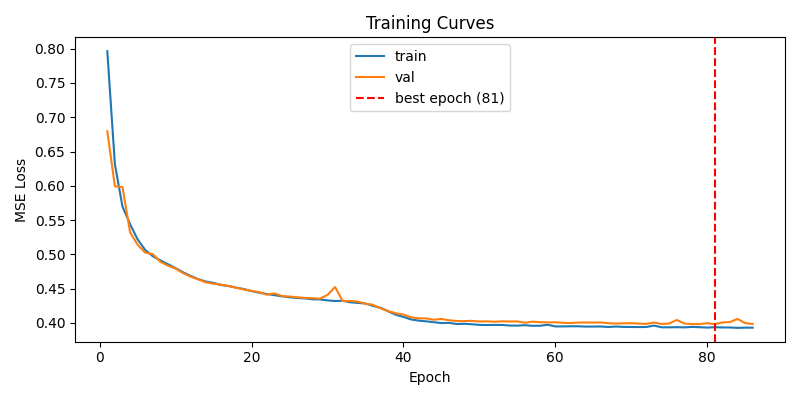

In [4]:
display(Image(str(Config.FIGURES_DIR / 'training_curves.png')))

Training ran for 86 epochs before early stopping (patience = 5) triggered.  
Both train and validation loss decrease steadily with no signs of overfitting — the model generalises well to unseen legitimate transactions.

## 5. Reconstruction error distribution

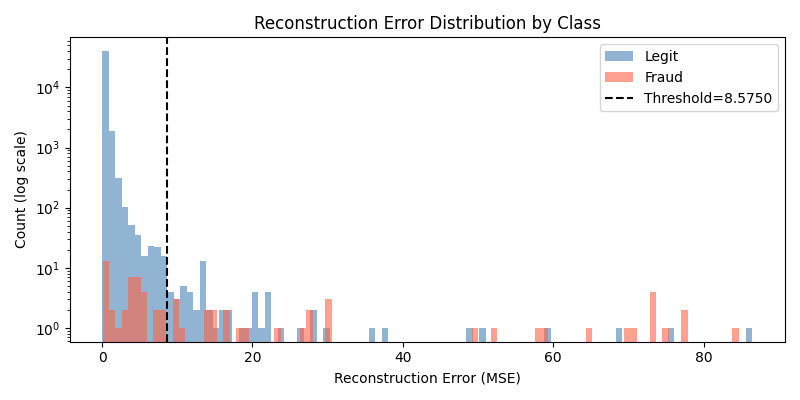

In [5]:
display(Image(str(Config.FIGURES_DIR / 'error_distribution.png')))

Legitimate transactions (blue) cluster at very low reconstruction errors.  
Fraud transactions (red) are spread over a broader, higher-error range — the autoencoder struggles to reconstruct patterns it was never trained on.  
The dashed vertical line is the F1-optimised threshold (≈ 8.58): transactions to the right are classified as fraud.

## 6. Precision-Recall curve

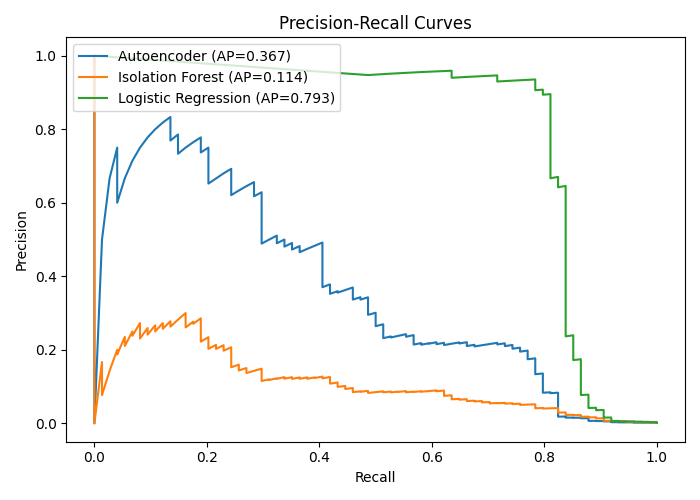

In [6]:
display(Image(str(Config.FIGURES_DIR / 'pr_curve.png')))

## 7. ROC curve

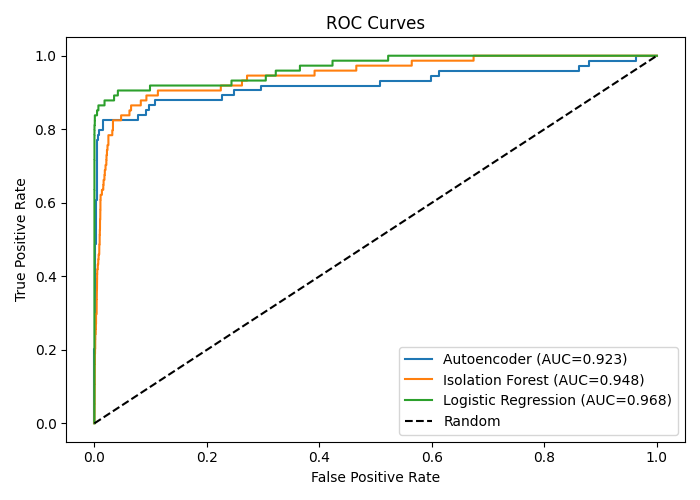

In [7]:
display(Image(str(Config.FIGURES_DIR / 'roc_curve.png')))

## 8. Confusion matrix (Autoencoder, F1-opt threshold)

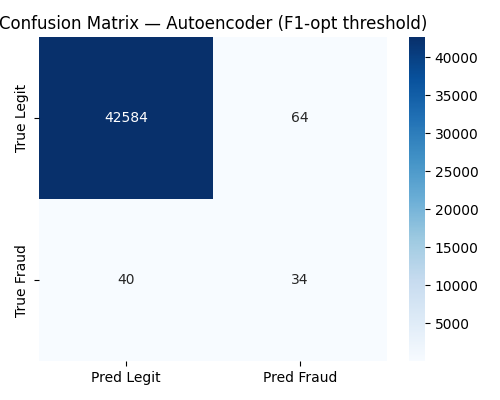

In [8]:
display(Image(str(Config.FIGURES_DIR / 'confusion_matrix.png')))

## 9. Analysis — What do the results tell us?

### What the comparison shows

| Dimension | Autoencoder | Isolation Forest | Logistic Regression |
|---|---|---|---|
| PR-AUC | 0.37 | 0.11 | **0.79** |
| ROC-AUC | 0.92 | 0.95 | **0.97** |
| Requires labels? | **No** | **No** | Yes |
| Generalises to novel fraud? | **Yes** | **Yes** | No (boundary fixed at train time) |

Logistic Regression wins on raw metrics — that is expected.  
It has access to the full label signal and a perfectly calibrated decision boundary on this static dataset.  
The autoencoder achieves PR-AUC of 0.37 with **zero exposure to fraud labels during training**,  
which is a meaningful result in the unsupervised setting.

Isolation Forest, despite being another unsupervised method, performs poorly on PR-AUC (0.11),  
suggesting it struggles with the high-dimensional PCA structure of this dataset.

### When would the autoencoder be the better choice?

- **Cold-start fraud patterns:** a new attack type has no labeled examples yet. The autoencoder flags it based on deviation from the learned legitimate distribution.
- **Label scarcity or noise:** real fraud teams often cannot label every suspicious transaction. The autoencoder requires no labels at all.
- **Concept drift:** fraud patterns evolve; the autoencoder can be periodically retrained on the growing stream of confirmed legitimate transactions.

### Limits of this approach

- **Threshold sensitivity:** the F1-opt threshold (8.58) is calibrated on the validation set. A shift in the legitimate transaction distribution at inference time can push this threshold out of alignment.
- **PR-AUC gap:** the 0.41 PR-AUC gap vs. Logistic Regression is large. A production system might blend both — use the autoencoder as a first-pass filter and the supervised model for confirmed-label cases.
- **High false-positive rate at useful recall:** at the F1-opt threshold, precision is 0.35 — one in three flagged transactions is legitimate. Cost-sensitive threshold tuning (with a real cost matrix) would be the next step.
- **Static architecture:** the 30→20→14→7→14→20→30 network was chosen for ONNX-export simplicity. A deeper or wider encoder might capture the fraud anomaly signal better.

## 10. Future work

- **In-browser demo** — ONNX Runtime Web + GitHub Pages (planned v2 deployment project)
- **Supervised baseline** — XGBoost with cost-sensitive weighting for a tighter performance ceiling estimate
- **Variational / denoising autoencoder** — the reconstruction probability from a VAE provides a principled anomaly score with better-calibrated uncertainty
- **Cost-sensitive threshold tuning** — replace F1-optimal threshold with one derived from a financial cost matrix (false negative cost >> false positive cost in fraud)
- **Concept-drift handling** — periodic retraining on a rolling window of confirmed legitimate transactions to track evolving spending patterns